# **بخش الف: بارگذاری و پیش‌پردازش داده‌ها**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score
from sklearn.preprocessing import StandardScaler

In [5]:
df = pd.read_csv('anti-malware.csv', na_values=['NA', 'NaN', ''])

print(f"dataset shape: {df.shape}")
df.head()

dataset shape: (10835, 312)


,NtDuplicateObject,NtOpenSection,CoUninitialize,RegCloseKey,LdrUnloadDll,DrawTextExW,GetSystemInfo,RegQueryValueExA,getaddrinfo,WSAStartup,...,CreateRemoteThreadEx,NtCreateDirectoryObject,EnumServicesStatusA,NtShutdownSystem,NtCreateProcessEx,NotifyBootConfigStatus,NtSaveKey,system,WNetGetProviderNameW,OUTPUT
0,0,0,0,0,0,2,0,0,0,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
1,2,2,0,10,0,4,1,0,0,1,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
2,5,2,2,96,2,15,3,116,2,1,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
3,9,13,5,662,37,0,0,405,0,1,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
4,3,2,2,94,3,17,4,116,2,1,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10835 entries, 0 to 10834
Columns: 312 entries, NtDuplicateObject to OUTPUT
dtypes: float64(177), int64(135)
memory usage: 25.8 MB


In [9]:
df.describe(include='all')

,NtDuplicateObject,NtOpenSection,CoUninitialize,RegCloseKey,LdrUnloadDll,DrawTextExW,GetSystemInfo,RegQueryValueExA,getaddrinfo,WSAStartup,...,CreateRemoteThreadEx,NtCreateDirectoryObject,EnumServicesStatusA,NtShutdownSystem,NtCreateProcessEx,NotifyBootConfigStatus,NtSaveKey,system,WNetGetProviderNameW,OUTPUT
count,10835.000000,10835.000000,10835.000000,10835.000000,10835.000000,10835.000000,10835.000000,10835.000000,10835.000000,10835.000000,...,10834.000000,10834.000000,10834.000000,10834.000000,10834.000000,10834.000000,10834.000000,10834.000000,10834.000000,10834.000000
mean,227.752192,18.478357,59.798062,913.181726,409.575819,150.773327,29.079465,55.712229,1.866636,3.669682,...,0.000462,0.000185,0.000554,0.000185,0.000092,0.000185,0.000369,0.002215,0.000554,0.778660
std,6166.434469,72.585300,556.099427,9051.417675,1758.145682,2377.705204,588.845994,563.524045,12.501254,78.941542,...,0.028820,0.013586,0.030378,0.013586,0.009607,0.019215,0.038430,0.221178,0.027169,0.415168
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.000000,0.000000,0.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
50%,6.000000,1.000000,2.000000,94.000000,3.000000,0.000000,1.000000,1.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
75%,40.000000,8.000000,18.000000,538.000000,26.000000,83.000000,16.000000,61.000000,0.000000,1.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
max,472673.000000,4999.000000,30583.000000,521175.000000,69261.000000,191106.000000,52762.000000,26399.000000,312.000000,8031.000000,...,2.000000,1.000000,2.000000,1.000000,1.000000,2.000000,4.000000,23.000000,2.000000,1.000000


In [10]:
X = df.drop('OUTPUT', axis=1)
y = df['OUTPUT']

In [11]:
numeric_cols = X.select_dtypes(include=['int64', 'float64']).columns
categorical_cols = X.select_dtypes(include=['object']).columns

In [12]:
numeric_cols

Index(['NtDuplicateObject', 'NtOpenSection', 'CoUninitialize', 'RegCloseKey',
       'LdrUnloadDll', 'DrawTextExW', 'GetSystemInfo', 'RegQueryValueExA',
       'getaddrinfo', 'WSAStartup',
       ...
       'DnsQuery_UTF8', 'CreateRemoteThreadEx', 'NtCreateDirectoryObject',
       'EnumServicesStatusA', 'NtShutdownSystem', 'NtCreateProcessEx',
       'NotifyBootConfigStatus', 'NtSaveKey', 'system',
       'WNetGetProviderNameW'],
      dtype='object', length=311)

In [13]:
categorical_cols

Index([], dtype='object')

In [15]:
num_imputer = SimpleImputer(strategy='mean')
cat_imputer = SimpleImputer(strategy='most_frequent')

X[numeric_cols] = num_imputer.fit_transform(X[numeric_cols])

if not categorical_cols.empty:
    X[categorical_cols] = cat_imputer.fit_transform(X[categorical_cols])

In [16]:
le = LabelEncoder()
y = le.fit_transform(y)

ohe = OneHotEncoder(handle_unknown='ignore', sparse_output=False)
X_cat = pd.DataFrame(ohe.fit_transform(X[categorical_cols]),
                     columns=ohe.get_feature_names_out(categorical_cols))

X = pd.concat([X[numeric_cols].reset_index(drop=True),
               X_cat.reset_index(drop=True)], axis=1)

In [18]:
scaler = StandardScaler()
X = scaler.fit_transform(X)

In [21]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Train: {X_train.shape[0]} sample | Test: {X_test.shape[0]} sample")

Train: 8668 sample | Test: 2167 sample


# **بخش ب: مدل رگرسیون لجستیکی**

In [22]:
lr = LogisticRegression(max_iter=1000, random_state=42)
lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)

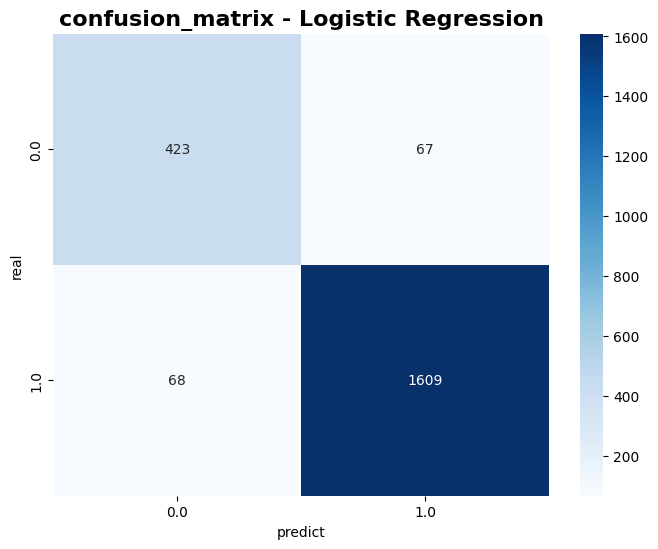

In [34]:
cm_lr = confusion_matrix(y_test, y_pred_lr)
plt.figure(figsize=(8,6))

actual_labels_in_test = np.unique(y_test)

sns.heatmap(cm_lr, annot=True, fmt='d', cmap='Blues',
            xticklabels=[str(le.classes_[label]) for label in actual_labels_in_test],
            yticklabels=[str(le.classes_[label]) for label in actual_labels_in_test])
plt.title('confusion_matrix - Logistic Regression', fontsize=16, fontweight='bold')
plt.xlabel('predict')
plt.ylabel('real')
plt.savefig('logistic_confusion_matrix.png', dpi=300, bbox_inches='tight')
plt.show()

In [33]:
filtered_target_names = [str(le.classes_[label]) for label in actual_labels_in_test]

print(classification_report(y_test, y_pred_lr, labels=actual_labels_in_test, target_names=filtered_target_names, zero_division=0))

              precision    recall  f1-score   support

         0.0       0.86      0.86      0.86       490
         1.0       0.96      0.96      0.96      1677

    accuracy                           0.94      2167
   macro avg       0.91      0.91      0.91      2167
weighted avg       0.94      0.94      0.94      2167



# **بخش ج: مدل Naive Bayes**

In [27]:
nb = GaussianNB()
nb.fit(X_train, y_train)
y_pred_nb = nb.predict(X_test)

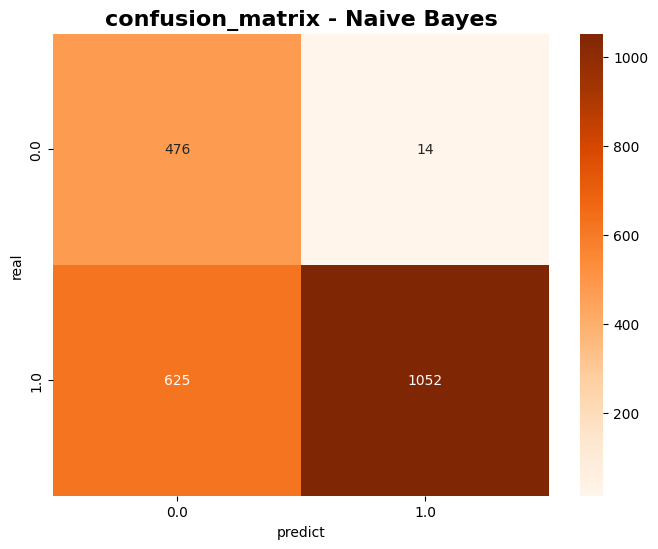

In [37]:
cm_nb = confusion_matrix(y_test, y_pred_nb)
plt.figure(figsize=(8,6))

actual_labels_in_test = np.unique(y_test)

sns.heatmap(cm_nb, annot=True, fmt='d', cmap='Oranges',
            xticklabels=[str(le.classes_[label]) for label in actual_labels_in_test],
            yticklabels=[str(le.classes_[label]) for label in actual_labels_in_test])
plt.title('confusion_matrix - Naive Bayes', fontsize=16, fontweight='bold')
plt.xlabel('predict')
plt.ylabel('real')
plt.savefig('naive_bayes_confusion_matrix.png', dpi=300, bbox_inches='tight')
plt.show()

In [38]:
actual_labels_in_test = np.unique(y_test)
filtered_target_names = [str(le.classes_[label]) for label in actual_labels_in_test]

print(classification_report(y_test, y_pred_nb, labels=actual_labels_in_test, target_names=filtered_target_names, zero_division=0))

              precision    recall  f1-score   support

         0.0       0.43      0.97      0.60       490
         1.0       0.99      0.63      0.77      1677

    accuracy                           0.71      2167
   macro avg       0.71      0.80      0.68      2167
weighted avg       0.86      0.71      0.73      2167



# **بخش د: مقایسه دو مدل**

In [41]:
acc_lr = accuracy_score(y_test, y_pred_lr)
acc_nb = accuracy_score(y_test, y_pred_nb)

print(f"Accuracy Logistic Regression = {acc_lr:.4f}")
print(f"Accuracy Naive Bayes         = {acc_nb:.4f}")

Accuracy Logistic Regression = 0.9377
Accuracy Naive Bayes         = 0.7051
